In [40]:
import pandas as pd

ads = pd.read_csv("../Data/Social_Network_Ads.csv")

ads.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


<Axes: xlabel='Purchased', ylabel='EstimatedSalary'>

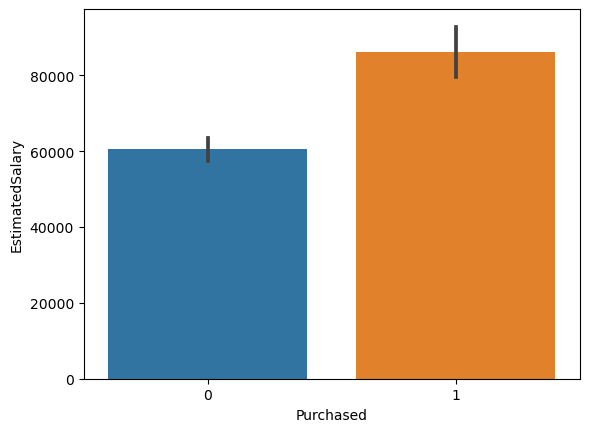

In [41]:
import seaborn as sns

sns.barplot(data=ads, x="Purchased", y="EstimatedSalary")

In [42]:
ads.describe().T

,count,mean,std,min,25%,50%,75%,max
User ID,400.0,1.569154e+07,71658.321581,15566689.0,15626763.75,15694341.5,15750363.0,15815236.0
Age,400.0,3.765500e+01,10.482877,18.0,29.75,37.0,46.0,60.0
EstimatedSalary,400.0,6.974250e+04,34096.960282,15000.0,43000.00,70000.0,88000.0,150000.0
Purchased,400.0,3.575000e-01,0.479864,0.0,0.00,0.0,1.0,1.0


In [4]:
from sklearn.model_selection import train_test_split

X = pd.get_dummies(ads[["Gender", "Age","EstimatedSalary"]], drop_first=True)
y = ads["Purchased"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2023)

In [43]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression() 

lr = logreg.fit(X_train, y_train)

In [44]:
print(f"Coefficients: {lr.coef_}") 
print(f"Intercept: {lr.intercept_}") 

Coefficients: [[-5.82819478e-03 -5.92319067e-07 -7.15206560e-04]]
Intercept: [-0.00127207]


In [45]:
lr.predict_proba(X_test)

array([[0.58183365, 0.41816635],
       [0.58210008, 0.41789992],
       [0.56720002, 0.43279998],
       [0.54962391, 0.45037609],
       [0.59154853, 0.40845147],
       [0.57896088, 0.42103912],
       [0.54065938, 0.45934062],
       [0.57373251, 0.42626749],
       [0.5434932 , 0.4565068 ],
       [0.57097792, 0.42902208],
       [0.5694332 , 0.4305668 ],
       [0.5708383 , 0.4291617 ],
       [0.54964189, 0.45035811],
       [0.57786261, 0.42213739],
       [0.54748733, 0.45251267],
       [0.58404126, 0.41595874],
       [0.58634583, 0.41365417],
       [0.58873456, 0.41126544],
       [0.59304227, 0.40695773],
       [0.56543236, 0.43456764],
       [0.57478036, 0.42521964],
       [0.54590312, 0.45409688],
       [0.55703607, 0.44296393],
       [0.58384442, 0.41615558],
       [0.56894404, 0.43105596],
       [0.56622993, 0.43377007],
       [0.56986882, 0.43013118],
       [0.59631924, 0.40368076],
       [0.58446611, 0.41553389],
       [0.555821  , 0.444179  ],
       [0.

In [46]:
lr.predict(X_test)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int64)

In [9]:
lr.intercept_

array([-0.00127207])

In [47]:
[f"{x}: {y}" for x,y in zip(list(X_train.columns), lr.coef_[0])]

['Age: -0.005828194782522964',
 'EstimatedSalary: -5.92319066615752e-07',
 'Gender_Male: -0.0007152065604118986']

In [11]:
print(f"Train Accuracy: {lr.score(X_train, y_train)}")
print(f"Test Accuracy: {lr.score(X_test, y_test)}")

Train Accuracy: 0.653125
Test Accuracy: 0.6


In [48]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, lr.predict(X_test))

array([[48,  0],
       [32,  0]], dtype=int64)

In [13]:
from sklearn.metrics import precision_score, recall_score

recall_score(y_test, lr.predict(X_test))

0.0

In [14]:
list(X_train.columns)

['Age', 'EstimatedSalary', 'Gender_Male']

In [15]:
pd.DataFrame({
    "Feature": X_train.columns, 
    "Coefficient": lr.coef_[0]
})

,Feature,Coefficient
0,Age,-5.828195e-03
1,EstimatedSalary,-5.923191e-07
2,Gender_Male,-7.152066e-04


In [16]:
lr.coef_

array([[-5.82819478e-03, -5.92319067e-07, -7.15206560e-04]])

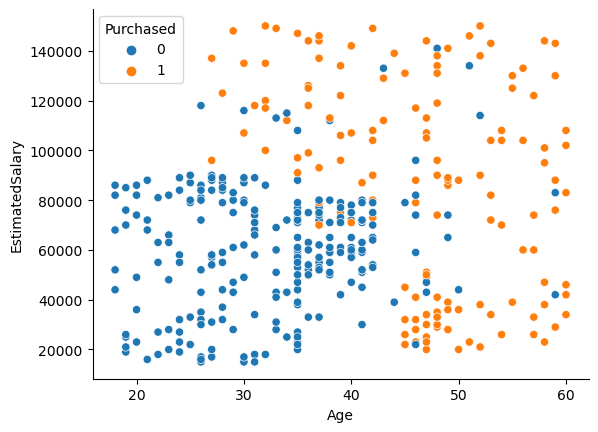

In [17]:
sns.scatterplot(ads, x="Age", y="EstimatedSalary", hue="Purchased");

sns.despine()

In [54]:
import numpy as np

ads = pd.get_dummies(
    ads.assign(
        age45 = np.where(ads["Age"] > 45, 1, 0),
        salary90 = np.where(ads["EstimatedSalary"] > 90000, 1, 0),
        agexsal = ads["Age"] * ads["EstimatedSalary"]
    ), 
    drop_first=True
)    

ads.head()

,User ID,Age,EstimatedSalary,Purchased,age45,salary90,agexsal,Gender_Male
0,15624510,19,19000,0,0,0,361000,True
1,15810944,35,20000,0,0,0,700000,True
2,15668575,26,43000,0,0,0,1118000,False
3,15603246,27,57000,0,0,0,1539000,False
4,15804002,19,76000,0,0,0,1444000,True


In [55]:
from sklearn.model_selection import train_test_split

X = pd.get_dummies(ads[["age45", "salary90"]], drop_first=True)
y = ads["Purchased"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2023)

print(
    f"Training Set Rows: {X.shape[0]}",
    f"Test Set Rows: {X_test.shape[0]}"
)

Training Set Rows: 400 Test Set Rows: 80


In [56]:
ads = pd.read_csv("../Data/Social_Network_Ads.csv")

X = pd.get_dummies(ads[["Gender", "Age","EstimatedSalary"]], drop_first=True)
y = ads["Purchased"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2023)

In [60]:
from sklearn.preprocessing import StandardScaler

std = StandardScaler()

X_train_std = std.fit_transform(X_train)
X_test_std = std.transform(X_test)

In [61]:
from sklearn.model_selection import GridSearchCV

parameters = {
    "C": np.linspace(.1, 2, 20),
    "penalty": ["l1", "l2"]
}

gridsearch = GridSearchCV(LogisticRegression(solver="saga"), parameters)

gridsearch.fit(X_train_std, y_train)

gridsearch.best_params_

{'C': 0.3, 'penalty': 'l1'}

In [59]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(C=.3, penalty="l1", solver="saga") 

lr = logreg.fit(X_train_std, y_train)

print(f"Train Accuracy: {lr.score(X_train_std, y_train)}")
print(f"Test Accuracy: {lr.score(X_test_std, y_test)}")

Train Accuracy: 0.853125
Test Accuracy: 0.875


In [62]:
lr.predict_proba(X_test)[:5]

c:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:457: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


array([[0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.]])